# Titanic Survival Prediction

This notebook builds a machine learning model to predict which passengers survived the Titanic disaster, using the classic [Kaggle Titanic competition](https://www.kaggle.com/c/titanic) dataset.

## Overview
The workflow covers:
1. **Data Loading** — read the training and test CSV files
2. **Exploratory Data Analysis (EDA)** — examine survival rates by gender, passenger class, and family size
3. **Feature Engineering** — bin continuous variables and encode categoricals
4. **Model Training** — train a Decision Tree classifier and compare with Logistic Regression
5. **Submission** — generate predictions for the test set and save to `submission.csv`

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


## 1. Environment Setup

Import core libraries (`numpy`, `pandas`) and verify that the Titanic input files are accessible in the Kaggle environment.

In [2]:
train_data = pd.read_csv("/kaggle/input/titanic/train.csv")
train_data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Data Loading

Load the training and test datasets. The training set contains 891 passengers with known survival labels; the test set contains 418 passengers whose survival we need to predict.

In [3]:
test_data = pd.read_csv("/kaggle/input/titanic/test.csv")
test_data.head()
test_data.PassengerId

0       892
1       893
2       894
3       895
4       896
       ... 
413    1305
414    1306
415    1307
416    1308
417    1309
Name: PassengerId, Length: 418, dtype: int64

## 3. Exploratory Data Analysis (EDA)

### 3a. Survival Rates by Gender

The "women and children first" evacuation policy suggests gender is a strong predictor of survival. We calculate the raw survival rate for female and male passengers separately.

In [ ]:
women = train_data.loc[train_data.Sex == 'female']["Survived"]
rate_women = sum(women)/len(women)

print("% of women who survived:", rate_women)

In [5]:
men = train_data.loc[train_data.Sex == 'male']["Survived"]
rate_men = sum(men)/len(men)

print("% of men who survived:", rate_men)

% of men who survived: 0.18890814558058924


In [6]:
print(train_data.columns)# Check for missing values in each column
missing_data = test_data.isnull().sum()

# Print the columns with missing values
print(missing_data)


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


### 3b. Missing Value Analysis

Identify columns with missing data that will need imputation before modeling. Key columns with missing values are `Age`, `Fare`, and `Cabin`.

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


### 3c. Survival by Passenger Class

A histogram faceted by survival status shows how passenger class (1st, 2nd, 3rd) correlates with survival. First-class passengers had significantly higher survival rates.

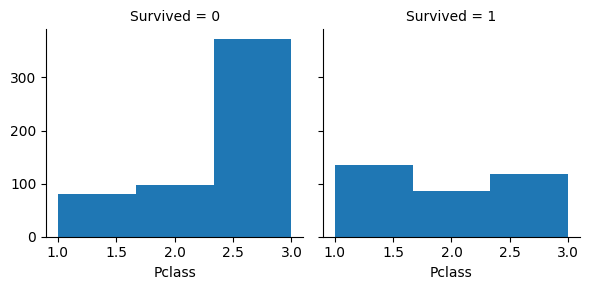

In [8]:
g = sns.FacetGrid(train_data, col='Survived')
g.map(plt.hist, 'Pclass', bins=3)


### 3d. Survival by Number of Parents/Children (Parch)

Passengers traveling with 1–3 family members (parents or children) had notably higher survival rates than solo travelers or those in very large family groups.

In [9]:
train_data[["Parch", "Survived"]].groupby(['Parch'], as_index=False).mean().sort_values(by='Survived', ascending=False)


,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


## 4. Feature Engineering & Model Training

Impute missing `Age` and `Fare` values with the median, then engineer categorical features:
- **CatAge** — age bins (infant, child, young, grownup, oldest survivor)
- **FamilySize** — total family members, bucketed into NoFamily / SmallFamily / BigFamily
- **FareCat** — fare quartile buckets
- **PclassCat** — passenger class as an ordered category

All categorical features are one-hot encoded with `pd.get_dummies`. A **Decision Tree** classifier is trained and validated (80/20 split), and its feature importances are reported. A **Logistic Regression** model is also fitted for comparison. Finally, predictions on the test set are written to `submission.csv`.

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
imputer = SimpleImputer(strategy='median')
train_data['Age'] = imputer.fit_transform(train_data[['Age']])
train_data['Fare'] = imputer.fit_transform(train_data[['Fare']])
train_data['CatAge']=pd.cut(train_data['Age'], bins=[0, 4, 16, 40, 75, 85], labels=['infant', 'child', 'young', 'grownup', 'oldest survivor'], right=True)
train_data['FamilySize'] = train_data['SibSp'] + train_data['Parch']
train_data['FamilySize'] = pd.cut(train_data['FamilySize'], bins=[-1, 0, 3, 40], labels=['NoFamily', 'SmallFamily', 'BigFamily'], right=True)
train_data['FareCat'] = pd.cut(train_data['Fare'], bins=[-1,7.9 , 14.454 , 31.47, 1000], labels=['cheapFare', 'mediumFare', 'medhighFare', 'expensiveFare'], right=True)
train_data['PclassCat'] = pd.cut(train_data['Pclass'], bins=[0, 1, 2, 3], labels=['1', '2', '3'], right=True)
train_data_selected_features = train_data[['PclassCat', 'Sex', 'CatAge', 'FamilySize', 'FareCat', 'Embarked']]
X = pd.get_dummies(train_data_selected_features)
y = train_data['Survived']
test_data['Age'] = imputer.fit_transform(test_data[['Age']])
test_data['Fare'] = imputer.fit_transform(test_data[['Fare']])
test_data['CatAge']=pd.cut(test_data['Age'], bins=[0, 4, 16, 40, 75, 85], labels=['infant', 'child', 'young', 'grownup', 'oldest survivor'], right=True)
test_data['FamilySize'] = test_data['SibSp'] + test_data['Parch']
test_data['FamilySize'] = pd.cut(test_data['FamilySize'], bins=[-1, 0 , 3, 40], labels=['NoFamily', 'SmallFamily', 'BigFamily'], right=True)
test_data['FareCat'] = pd.cut(test_data['Fare'], bins=[-1, 7.9, 14.454, 31.47, 1000], labels=['cheapFare', 'mediumFare', 'medhighFare', 'expensiveFare'], right=True)
test_data['PclassCat'] = pd.cut(test_data['Pclass'], bins=[0, 1, 2, 3], labels=['1', '2', '3'], right=True)
X_test = test_data[['PclassCat', 'Sex', 'CatAge', 'FamilySize', 'FareCat' , 'Embarked']]
X_test = pd.get_dummies(X_test)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred):.4f}")


lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
print("Accuracy on training set:", lr_model.score(X_val, y_val))
predictions = model.predict(X_test)
# Get the feature importances
importances = model.feature_importances_

# Sort feature importances
sorted_indices = np.argsort(importances)[::-1]

# Print feature importance
for idx in sorted_indices:
    print(f"{X.columns[idx]}: {importances[idx]}")
output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")


Validation Accuracy: 0.8101
Accuracy on training set: 0.8100558659217877
Sex_female: 0.49125708885813785
PclassCat_3: 0.1398658270401452
FamilySize_BigFamily: 0.08235555402720932
CatAge_infant: 0.055729519791420434
PclassCat_1: 0.03956253629213841
FamilySize_SmallFamily: 0.030662003427482255
FareCat_mediumFare: 0.022447121788340157
FamilySize_NoFamily: 0.01844604108481072
Embarked_C: 0.01562214807161604
Embarked_S: 0.015267484062436007
CatAge_young: 0.014774872576820827
FareCat_cheapFare: 0.013904238066812288
CatAge_grownup: 0.013258724857902662
FareCat_expensiveFare: 0.012805857984723947
PclassCat_2: 0.011254645289544838
CatAge_child: 0.009185811102323393
FareCat_medhighFare: 0.005408371129855349
CatAge_oldest survivor: 0.004296664098704567
Embarked_Q: 0.003895490449575718
Sex_male: 0.0
Your submission was successfully saved!
